# Aggregate Supply & Consumer Sentiment Dashboard

Merge SPF forecasts with FRED consumer series, NY Fed GSCPI, gasoline prices, and unemployment. Run analytics and save regime figures.

In [1]:
from pathlib import Path

from dotenv import load_dotenv

from src.analytics import (
    format_granger_summary,
    granger_gscpi_causes_mich,
    rolling_correlation_gscpi_umcsent,
)
from src.data_loader import build_master_frame, fetch_monthly_for_plots
from src.plots import plot_expectations_gap, plot_macro_regimes

load_dotenv()

df = build_master_frame(start="2018-01-01")
monthly = fetch_monthly_for_plots(start="2018-01-01")

In [2]:
df.head()

,spf_cpi_1yr,gscpi,mich,umcsent,gasregw,unrate
quarter_end,,,,,,
2018-03-31 00:00:00.000000,2.211700,0.356667,2.733333,98.933333,2.577700,4.033333
2018-03-31 23:59:59.999999,2.211700,0.357582,2.734432,98.926740,2.580687,4.032234
2018-06-30 00:00:00.000000,2.259173,0.440000,2.833333,98.333333,2.849500,3.933333
2018-06-30 23:59:59.999999,2.259700,0.440399,2.833696,98.330435,2.849396,3.931522
2018-09-30 00:00:00.000000,2.258909,0.476667,2.866667,98.066667,2.839950,3.766667


In [3]:
df.info()
print("Missing values per column:")
print(df.isna().sum())

<class 'pandas.DataFrame'>
DatetimeIndex: 68 entries, 2018-03-31 00:00:00 to 2026-06-30 23:59:59.999999
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   spf_cpi_1yr  68 non-null     float64
 1   gscpi        68 non-null     float64
 2   mich         68 non-null     float64
 3   umcsent      68 non-null     float64
 4   gasregw      68 non-null     float64
 5   unrate       68 non-null     float64
dtypes: float64(6)
memory usage: 3.7 KB
Missing values per column:
spf_cpi_1yr    0
gscpi          0
mich           0
umcsent        0
gasregw        0
unrate         0
dtype: int64


In [4]:
control_cols = ["gscpi", "mich", "umcsent", "spf_cpi_1yr", "gasregw", "unrate"]
df[control_cols].corr()

,gscpi,mich,umcsent,spf_cpi_1yr,gasregw,unrate
gscpi,1.000000,0.363720,-0.101038,0.086558,0.059180,0.386920
mich,0.363720,1.000000,-0.770458,0.798622,0.683277,-0.196722
umcsent,-0.101038,-0.770458,1.000000,-0.680130,-0.657112,0.007909
spf_cpi_1yr,0.086558,0.798622,-0.680130,1.000000,0.815275,-0.467230
gasregw,0.059180,0.683277,-0.657112,0.815275,1.000000,-0.532509
unrate,0.386920,-0.196722,0.007909,-0.467230,-0.532509,1.000000


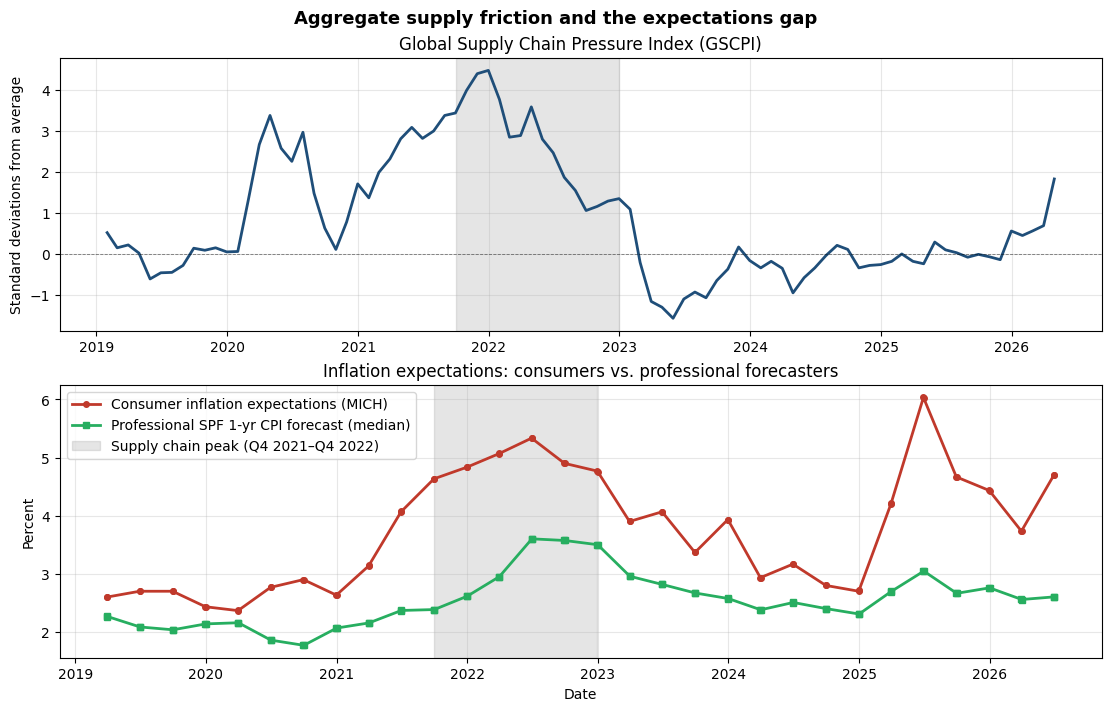

In [5]:
import matplotlib.pyplot as plt

Path("figures").mkdir(exist_ok=True)

fig_gap = plot_expectations_gap(df, monthly["gscpi"], plot_start="2019-01-01", plot_end="2026-12-31")
fig_gap.savefig("figures/friction_sentiment.png", dpi=150, bbox_inches="tight")
plt.show()

In [6]:
pvalues = granger_gscpi_causes_mich(df, max_lag=3)
print(format_granger_summary(pvalues))

Granger causality test (SSR F-test, H0: lagged GSCPI does not help predict MICH)
Specification: MICH on lagged MICH and lagged GSCPI.

  Lag 1: p = 0.1698  →  fail to reject H0 at 5% (not significant predictive content from GSCPI).
  Lag 2: p = 0.3623  →  fail to reject H0 at 5% (not significant predictive content from GSCPI).
  Lag 3: p = 0.4701  →  fail to reject H0 at 5% (not significant predictive content from GSCPI).

Summary: No lag up to 3 provides statistically significant evidence that GSCPI Granger-causes MICH at 5%.


c:\Users\jayhu\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


quarter_end
2025-12-31 23:59:59.999999   -0.317234
2026-03-31 00:00:00.000000   -0.383703
2026-03-31 23:59:59.999999   -0.435583
2026-06-30 00:00:00.000000   -0.602987
2026-06-30 23:59:59.999999   -0.719021
Name: roll_corr_gscpi_umcsent_24m, dtype: float64


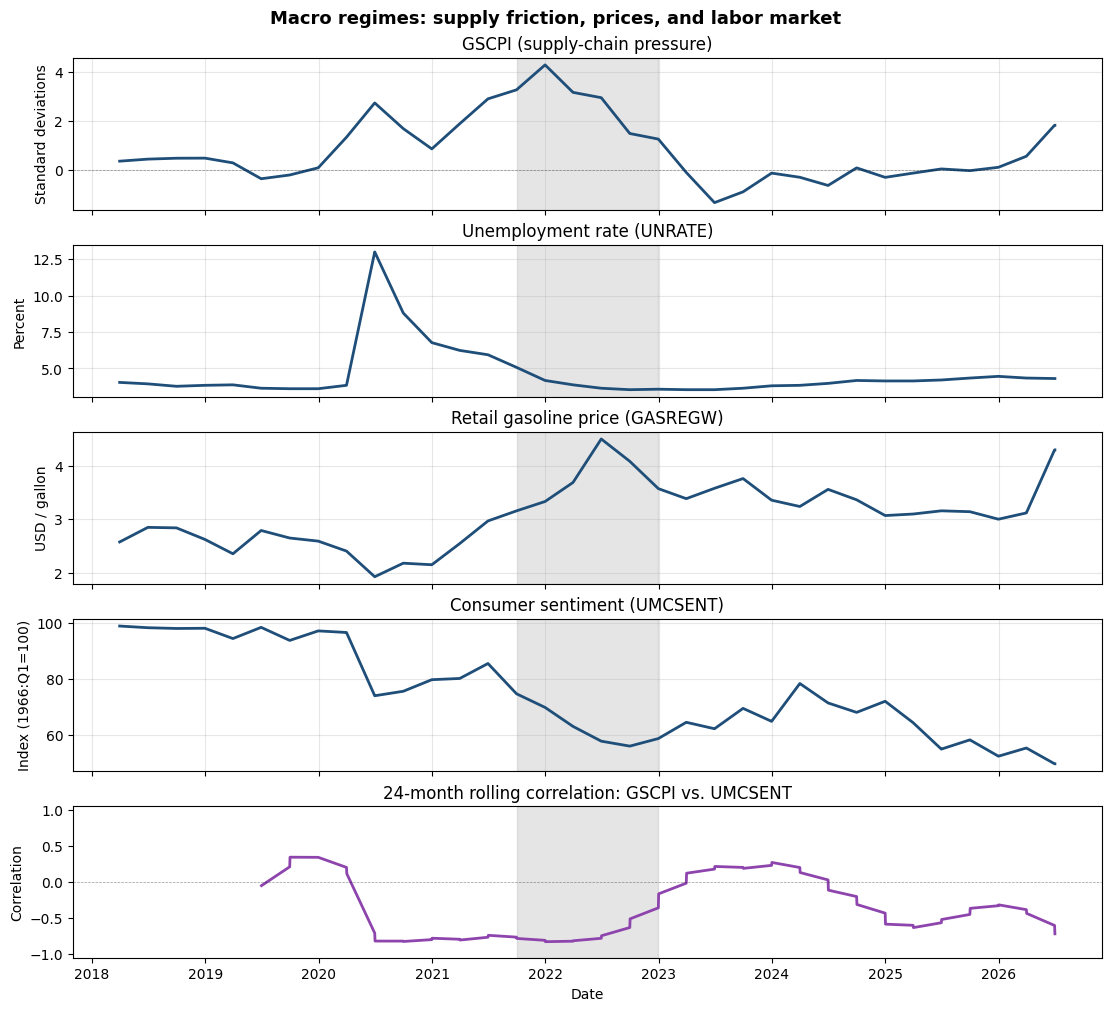

In [7]:
roll_corr = rolling_correlation_gscpi_umcsent(df, window_months=24)
print(roll_corr.dropna().tail())

fig_regimes = plot_macro_regimes(df, rolling_corr=roll_corr, plot_start="2018-01-01")
fig_regimes.savefig("figures/macro_regimes.png", dpi=150, bbox_inches="tight")
plt.show()